# AI Application Patterns

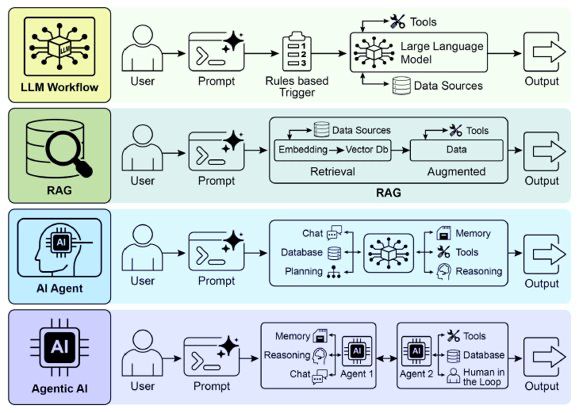

In [1]:
import pkg_resources
version = pkg_resources.get_distribution("ibm-watsonx-gov").version
print(f"Installed version: {version}")

Installed version: 1.3.3.6


/var/folders/hv/4ht9pmcd5qb2kpzglzb7k_kh0000gn/T/ipykernel_1513/221110328.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


# Env Vars

In [2]:
# Load environment variables from .env file

from dotenv import load_dotenv

load_dotenv()

True

# Create Test Questions

In [3]:
import pandas as pd
import uuid

pd.set_option('display.max_columns', None)

questions = [
    "What was the record of the New England Patriots for the 2024 season?",
    "What's the emergency contact number for the electric utility?",
    "How many stars on the United States flag?",
    "What is the address of Municipal Electric Commission?",
    "What year did the town of mansfield vote to establish a Municipal Lighting Plant?"
]

question_df = pd.DataFrame({"input_text": questions})
question_df["interaction_id"] = question_df.index.astype(str)
question_df["message_id"] = [str(uuid.uuid4()) for _ in range(len(question_df))]
question_df

,input_text,interaction_id,message_id
0,What was the record of the New England Patriot...,0,11d59f4e-82d5-4ee3-9476-9b32ca9fc8dd
1,What's the emergency contact number for the el...,1,34867d2b-361b-46e6-be9a-8f04b1d3603e
2,How many stars on the United States flag?,2,fbab6b58-e512-473d-9ca1-44859b302092
3,What is the address of Municipal Electric Comm...,3,94009c30-4ae7-4b51-a097-2b27de4fef31
4,What year did the town of mansfield vote to es...,4,f7b46b59-ba5a-4cb3-a6f6-00caa7bc6ba9


# Initialize Agentic Evaluator

In [4]:
from ibm_watsonx_gov.entities.state import EvaluationState
from typing import Optional, TypedDict

class AppState(TypedDict):
    input_text: str # The user's raw input query or question
    context: list[str] # Context fetched from vectordb
    web_context: list[str] # Context fetched from tavily search
    generated_text: str # The final output generated by the LLM after processing all contexts
    message_id: str # An unique id used to track the metric results



In [5]:
from ibm_watsonx_gov.evaluators.agentic_evaluator import AgenticEvaluator
from ibm_watsonx_gov.metrics import FaithfulnessMetric, ContextRelevanceMetric
from ibm_watsonx_gov.evaluators.agentic_evaluator import AgenticEvaluator
from ibm_watsonx_gov.config import AgenticAIConfiguration
from ibm_watsonx_gov.config.agentic_ai_configuration import TracingConfiguration
from ibm_watsonx_gov.entities.foundation_model import WxAIFoundationModel
from ibm_watsonx_gov.entities.llm_judge import LLMJudge

import os

PROJECT_ID = os.getenv("WATSONX_PROJECT_ID")

llm_judge = LLMJudge(
    model=WxAIFoundationModel(
        model_id="meta-llama/llama-3-3-70b-instruct",
        project_id=PROJECT_ID,
    )
)

evaluator = AgenticEvaluator(tracing_configuration=TracingConfiguration(project_id=os.getenv("WATSONX_PROJECT_ID")))

/Users/jordanprickett/Documents/Dev/wx-gov-rag/watsonx-governance-sdk-demos/rag-agent-demo/.venv/lib/python3.11/site-packages/ibm_watsonx_gov/tools/utils/environment.py:55: UserWarning: Since WATSONX_REGION is not provided in the environment variable, the Dallas region will be used as the default.
  warnings.warn(


Custom exporter logging initialized. App name: Jordans_ipykernel_launcher
Traceloop exporting traces to a custom exporter

Metrics are disabled


# Basic RAG Agent

In [6]:
# Load documents from the data directory

from langchain_community.document_loaders import DirectoryLoader, PyMuPDFLoader

directory_loader = DirectoryLoader("data", glob="**/*.pdf", loader_cls=PyMuPDFLoader)
docs = directory_loader.load()

In [7]:
# Chunk the documents

from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=450,
    chunk_overlap=50,
)

chunks = text_splitter.split_documents(docs)
len(chunks)

890

In [8]:
# Get the embedding model

from langchain_ibm.embeddings import WatsonxEmbeddings

embeddings = WatsonxEmbeddings(
    model_id="ibm/slate-30m-english-rtrvr-v2",
    url="https://us-south.ml.cloud.ibm.com",
    # apikey=os.environ["WATSONX_APIKEY"],
    project_id=os.environ["WATSONX_PROJECT_ID"],
)


In [9]:
# Create a Qdrant vector store in memory

from langchain_community.vectorstores import Qdrant
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams

colllection_name = "utility-docs"

# Initialize the Qdrant client
qdrant_client = QdrantClient(location=":memory:")

# Create a collection in Qdrant
qdrant_client.create_collection(
    collection_name=colllection_name, 
    vectors_config=VectorParams(size=384, distance=Distance.COSINE)
)

# Initialize QdrantVectorStore with the Qdrant client
qdrant_vector_store = QdrantVectorStore(
    client=qdrant_client, 
    collection_name=colllection_name, 
    embedding=embeddings
)

# Add the docs to the vector store
qdrant_vector_store.add_documents(chunks)

['c6738a65c4b8446a8a0b12cad14b5f1c',
 '82690672465d4350929412817d51d035',
 'e3ba9c90ece0407bad8cf528078e7c80',
 'b1d0038048494bada79b6a0de0a367ae',
 '3574dbce8f9f4e1f941471579ef0a404',
 '169182903f6a4061b869a1333e187923',
 'dfd4eca07d774df0a8f8cf2e6f35fe66',
 '595b130e0633477d8eb83ede39fa216b',
 '227afe97ca4e4167965f469f7e2394d8',
 'c9e2cc12f5eb4d4fb4cab8ccce186471',
 'cd24ff962669499dbfebea98c3512dac',
 'fc3f62258e594430ab8a281cc9aa7d45',
 'cd11a52021f1473db28ab187cc296eef',
 '6f81ebaab7f34c82b6b55162e0fd5672',
 'e63b52206a1f4f5d9047438951c5809c',
 'a92cfc23ad86473ca50c7344800c79ba',
 'df9838e854be48a681e0e833feac49cc',
 'ed332d54aa0f40dbac45ae85c6f038ed',
 'abecd684ecb24e4eaee36948f89b7e1f',
 '9a7342717c764413802f45bc7b10618e',
 '368461c17c994ad490b2762d9b373f6d',
 'ed445ccf5c6c4d56a6e3ea3aadbe2504',
 '42dc0d85a2de4fed88f68f3d4163ab11',
 'aecd903ecc9a4b9fa185e95b39bda47f',
 '53f1eb5893ba4c89a62f2766eccdc659',
 '045b5319ea5d4da1960730f02634a82c',
 '7961e8168bd8404f87cbc158c013b300',
 

In [10]:
# Create a retriever - "R" in RAG

retriever = qdrant_vector_store.as_retriever()

In [11]:
# Create a simple prompt

from langchain_core.prompts import ChatPromptTemplate

HUMAN_TEMPLATE = """
CONTEXT:
{context}

QUERY:
{query}

Use the provided context to answer the provided user query. Only use the provided context to answer the query. If you do not know the answer, or it's not contained in the provided context respond with "I don't know"
"""

chat_prompt = ChatPromptTemplate.from_messages([
    ("human", HUMAN_TEMPLATE)
])

generate_prompt = ChatPromptTemplate.from_template(
    "CONTEXT: {context}\n"
    "QUERY: {query}\n"
    "Use the provided context to answer the provided user query. Only use the provided context to answer the query. If you do not know the answer, or it's not contained in the provided context respond with \"I don't know\"\n"
    "ANSWER:"
)

In [12]:
# Create the chat model
from langchain_ibm import ChatWatsonx

parameters = {
    "temperature": 0.9,
    "repetition_penalty": 1.05,
    "max_tokens": 200,
}

chat_model = ChatWatsonx(
    model_id="meta-llama/llama-3-3-70b-instruct",
    url="https://us-south.ml.cloud.ibm.com",
    project_id=os.environ["WATSONX_PROJECT_ID"],
    params=parameters,
)

In [13]:
from tavily import TavilyClient
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")
tavily = TavilyClient(api_key=TAVILY_API_KEY)

from langchain_core.output_parsers import StrOutputParser
from langgraph.graph import START, END, StateGraph
from langgraph.config import RunnableConfig
import time

# qdrant retrieval
retrieve_node_config = {
    "input_fields": ["input_text"],
    "context_fields": ["context"],
    "message_id": ["message_id"]
}

@evaluator.evaluate_retrieval_quality(
    configuration=AgenticAIConfiguration(
        **retrieve_node_config),
        metrics=[ContextRelevanceMetric(llm_judge=llm_judge)],
        compute_real_time=True
)
def retrieve(state: AppState, config: RunnableConfig) -> dict:
    retrieved_docs = retriever.invoke(state["input_text"])
    context_strings = [doc.page_content for doc in retrieved_docs]
    return {"context": context_strings}

# web retrieval
retrieve_web_node_config = {
    "input_fields": ["input_text"],
    "context_fields": ["web_context"],
    "message_id": ["message_id"]
}

@evaluator.evaluate_retrieval_quality(
    configuration=AgenticAIConfiguration(
        **retrieve_web_node_config),
        metrics=[ContextRelevanceMetric(llm_judge=llm_judge)],
        compute_real_time=True
)
def retrieve_web(state: AppState, config: RunnableConfig) -> dict:
    print("Using Web Retrieval")
    search_result = tavily.search(
        query=state["input_text"],
        search_depth="basic",  # or "advanced" for deeper search
        max_results=5,
        include_answer=True,
        include_raw_content=False
    )

    # Process results with priority to answer if available
    results = []
    if search_result.get("answer"):
        results.append(f"Direct answer: {search_result['answer']}")

    # Add relevant context from top results
    for result in search_result.get("results", [])[:5]:
        if content := result.get("content"):
            results.append(f"From {result['url']}: {content}")

    return {
        "web_context": results[:5]
    }

# generate from qdrant context
generate_node_config = {
    "input_fields": ["input_text"],
    "context_fields": ["context"],
    "output_fields": ["generated_text"]
}

@evaluator.evaluate_faithfulness(
    configuration=AgenticAIConfiguration(
        **generate_node_config),
        metrics=[FaithfulnessMetric(llm_judge=llm_judge)],
        compute_real_time=True
)
def generate(state: AppState, config: RunnableConfig) -> dict:    
    formatted_prompt = generate_prompt.invoke(
        {"query": state["input_text"], "context": "\n".join(state["context"])}
    )
    response = chat_model.invoke(formatted_prompt)
    return {"generated_text": response.content}

# generate from web context
generate_web_node_config = {
    "input_fields": ["input_text"],
    "context_fields": ["web_context"],
    "output_fields": ["generated_text"]
}

@evaluator.evaluate_faithfulness(
    configuration=AgenticAIConfiguration(
        **generate_web_node_config),
        metrics=[FaithfulnessMetric(llm_judge=llm_judge)],
        compute_real_time=True
)
def generate_web(state: AppState, config: RunnableConfig) -> dict:    
    formatted_prompt = generate_prompt.invoke(
        {"query": state["input_text"], "context": "\n".join(state["web_context"])}
    )
    response = chat_model.invoke(formatted_prompt)
    return {"generated_text": response.content}

def check_context_relevance(state: AppState, config: RunnableConfig) -> str:
    try:
        print(f"=== State message_id: {state.get('message_id')} ===")
        
        target_message_id = state.get('message_id')
        
        # access trace results directly
        online_metrics = evaluator._AgenticEvaluator__online_metric_results
        
        found_metric_obj = None
        
        for metric in online_metrics:
            if (metric.name == "context_relevance" and 
                metric.node_name == "retrieve" and 
                metric.message_id == target_message_id):
                found_metric_obj = metric
                break
        
        if found_metric_obj and found_metric_obj.value is not None:
            if found_metric_obj.value > 0.4:
                print(f"High Context Relevance Score: {found_metric_obj.value}")
                return "Context Relevance Score is Good"
            else:
                print(f"Low Context Relevance Score: {found_metric_obj.value}")
                return "Context Relevance Score is Bad"
        else:
            print("Metric object not found or value is None in online results")
            return "Context Relevance Score is Bad"
            
    except Exception as e:
        print(f"Error getting metric: {e}")
        return "Context Relevance Score is Bad"


In [14]:
# Build the graph
builder = StateGraph(AppState)
builder.add_node("retrieve", retrieve)
builder.add_node("retrieve_web", retrieve_web)
builder.add_node("generate", generate)
builder.add_node("generate_web", generate_web)

builder.add_edge(START, "retrieve")
builder.add_conditional_edges(
    "retrieve",
    check_context_relevance,
    {
        "Context Relevance Score is Good": "generate",
        "Context Relevance Score is Bad": "retrieve_web",
    },
)
builder.add_edge("retrieve_web", "generate_web")
builder.add_edge("generate", END)
builder.add_edge("generate_web", END)

rag_agent = builder.compile()

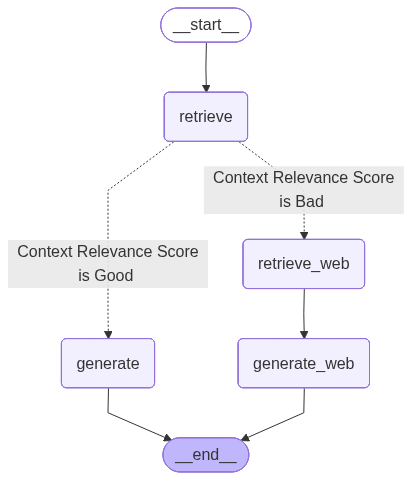

In [15]:
from IPython.display import Image, display

display(Image(rag_agent.get_graph(xray=True).draw_mermaid_png()))

## Test the Agentic Evaluator on a multiple inputs

In [16]:
batch_results = []
agent_results = []

for _, row in question_df.iterrows():
    evaluator.start_run()
    result = rag_agent.invoke({
        "input_text": row["input_text"],
        "interaction_id": row["interaction_id"],
        "message_id": row["message_id"],  # Generate new message_id for each run
        "record_id": row["message_id"],
    })
    evaluator.end_run()
    
    # Store agent result with message_id
    agent_results.append({
        "message_id": row["message_id"],
        "input_text": row["input_text"],
        "generated_text": result["generated_text"]
    })
    
    print(f"Input Text: {row['input_text']}\nGenerated Text: {result['generated_text']}\n")
    # Get metric results
    eval_result = evaluator.get_result()
    metric_result = eval_result.to_df()
    metric_result["message_id"] = row["message_id"]
    batch_results.append(metric_result)



[Warning] No region provided : Using default region as us-south
=== State message_id: 11d59f4e-82d5-4ee3-9476-9b32ca9fc8dd ===
Low Context Relevance Score: 0.0
Using Web Retrieval
Input Text: What was the record of the New England Patriots for the 2024 season?
Generated Text: The New England Patriots finished the 2024 season with a 4-13 record.

=== State message_id: 34867d2b-361b-46e6-be9a-8f04b1d3603e ===
High Context Relevance Score: 0.8
Input Text: What's the emergency contact number for the electric utility?
Generated Text: The emergency contact number for the electric utility is 508-261-7361.

=== State message_id: fbab6b58-e512-473d-9ca1-44859b302092 ===
Low Context Relevance Score: 0.0
Using Web Retrieval
Input Text: How many stars on the United States flag?
Generated Text: The United States flag has 50 stars, representing the 50 states. This design has been in place since 1959.

=== State message_id: 94009c30-4ae7-4b51-a097-2b27de4fef31 ===
High Context Relevance Score: 1.0
In

In [17]:
# Combine all metric results
metric_results = pd.concat(batch_results, ignore_index=True)

# Create agent results dataframe
agent_df = pd.DataFrame(agent_results)

final_df = agent_df.merge(metric_results, on="message_id")
display(final_df)

,message_id,input_text,generated_text,generate_web.faithfulness,generate_web.latency,message.cost,message.duration,message.input_token_count,message.output_token_count,retrieve.average_precision,retrieve.context_relevance,retrieve.hit_rate,retrieve.latency,retrieve.ndcg,retrieve.reciprocal_rank,retrieve.retrieval_precision,retrieve_web.average_precision,retrieve_web.context_relevance,retrieve_web.hit_rate,retrieve_web.latency,retrieve_web.ndcg,retrieve_web.reciprocal_rank,retrieve_web.retrieval_precision,generate.faithfulness,generate.latency
0,11d59f4e-82d5-4ee3-9476-9b32ca9fc8dd,What was the record of the New England Patriot...,The New England Patriots finished the 2024 sea...,1.0,2.8652,0.0009,37.1691,1221.0,19.0,0.0,0.0,0.0,30.6229,1.0,0.0,0.0,1.0,1.0,1.0,3.4585,1.0,1.0,1.0,NaN,NaN
1,34867d2b-361b-46e6-be9a-8f04b1d3603e,What's the emergency contact number for the el...,The emergency contact number for the electric ...,NaN,NaN,0.0004,2.8526,479.0,18.0,1.0,0.8,1.0,1.1616,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.6706
2,fbab6b58-e512-473d-9ca1-44859b302092,How many stars on the United States flag?,"The United States flag has 50 stars, represent...",1.0,2.2759,0.0006,6.5262,761.0,27.0,0.0,0.0,0.0,1.3613,1.0,0.0,0.0,1.0,1.0,1.0,2.8587,1.0,1.0,1.0,NaN,NaN
3,94009c30-4ae7-4b51-a097-2b27de4fef31,What is the address of Municipal Electric Comm...,The address of the Municipal Electric Commissi...,NaN,NaN,0.0004,3.4613,509.0,28.0,1.0,1.0,1.0,1.2668,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.1719
4,f7b46b59-ba5a-4cb3-a6f6-00caa7bc6ba9,What year did the town of mansfield vote to es...,The town of Mansfield voted to establish a Mun...,NaN,NaN,0.0004,2.4618,602.0,20.0,1.0,1.0,1.0,1.0445,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.3876


In [18]:
evaluator.get_nodes()

[Node(name='generate_web', func_name='generate_web', metrics_configurations=[], foundation_models=[FoundationModelInfo(model_name='meta-llama/llama-3-3-70b-instruct', model_id=None, provider='ibm', type='chat')]),
 Node(name='retrieve_web', func_name='retrieve_web', metrics_configurations=[], foundation_models=[]),
 Node(name='retrieve', func_name='retrieve', metrics_configurations=[], foundation_models=[]),
 Node(name='generate', func_name='generate', metrics_configurations=[], foundation_models=[FoundationModelInfo(model_name='meta-llama/llama-3-3-70b-instruct', model_id=None, provider='ibm', type='chat')])]